In [1]:
import io
import os
import fnmatch
from typing import Optional
import paramiko
import pandas as pd

def fetch_and_concat_csvs(
    ip: str,
    user: str,
    password: str,
    remote_dir: str,
    pattern: str = "df_metrics*",
    port: int = 22,
    return_csv_string: bool = False,
    timeout: Optional[float] = 10.0,
) -> pd.DataFrame:
    """
    Se connecte en SFTP et télécharge/télécharge en mémoire tous les fichiers
    du dossier `remote_dir` qui correspondent au `pattern` (fnmatch), lit les CSV,
    ajoute une colonne 'file' contenant le nom du fichier, concatène et renvoie
    le DataFrame final.

    Paramètres
    ----------
    ip, user, password : str
        Informations de connexion SSH.
    remote_dir : str
        Dossier distant à parcourir (chemin absolu ou relatif à l'utilisateur SFTP).
    pattern : str
        Pattern shell-style (ex: 'df_metrics*').
    port : int
        Port SSH (par défaut 22).
    return_csv_string : bool
        Si True, renvoie une tuple (DataFrame, csv_string). Sinon seulement DataFrame.
    timeout : float|None
        Timeout connexion en secondes.

    Retour
    ------
    pd.DataFrame
        DataFrame pandas concaténé contenant tous les enregistrements et une colonne 'file'.
        (ou (DataFrame, csv_string) si return_csv_string=True)
    """

    # Prépare le client SSH / SFTP
    transport = None
    sftp = None
    try:
        # Connexion SSH (transport)
        transport = paramiko.Transport((ip, port))
        transport.connect(username=user, password=password)
        # Ouvrir SFTP
        sftp = paramiko.SFTPClient.from_transport(transport)

        # Lister fichiers dans le répertoire distant
        try:
            files = sftp.listdir(remote_dir)
        except IOError:
            # Peut-être remote_dir non trouvé ; relancer en absolu ou lever l'erreur
            raise

        # Filtrer par pattern
        matched = [f for f in files if fnmatch.fnmatch(f, pattern)]
        if not matched:
            # Aucun fichier trouvé : renvoyer DataFrame vide
            empty_df = pd.DataFrame()
            if return_csv_string:
                return empty_df, ""
            return empty_df

        dfs = []
        for fname in matched:
            if 'volting' in fname or 'federated' in fname:
                continue
            print(fname)
            #if 'tree' not in fname:
            #    continue
            remote_path = os.path.join(remote_dir, fname)
            # Ouvre en binaire, lit tout en mémoire
            with sftp.open(remote_path, "rb") as remote_file:
                raw = remote_file.read()
            # Tenter de lire avec pandas
            # On essaie d'abord BytesIO (pandas gère souvent les bytes),
            # sinon on décode en utf-8 en tolérant les erreurs.
            df = None
            try:
                df = pd.read_csv(io.BytesIO(raw))
            except Exception:
                # try decoding then StringIO
                try:
                    txt = raw.decode("utf-8", errors="replace")
                    df = pd.read_csv(io.StringIO(txt))
                except Exception as e:
                    # En cas d'échec, lever une erreur explicite
                    raise RuntimeError(f"Impossible de parser le CSV distant {remote_path!r}: {e}")

            # Ajouter colonne 'file' avec le nom du fichier (basename)
            df["file"] = os.path.basename(fname)
            dfs.append(df)

        # Concaténer
        final_df = pd.concat(dfs, ignore_index=True, sort=False)

        if return_csv_string:
            csv_str = final_df.to_csv(index=False)
            return final_df, csv_str

        return final_df

    finally:
        # Fermeture propre des connexions
        if sftp is not None:
            try:
                sftp.close()
            except Exception:
                pass
        if transport is not None:
            try:
                transport.close()
            except Exception:
                pass

In [ ]:
IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/full_all_departement_0_None_node"

df = fetch_and_concat_csvs(IP, USER, PASSWORD, REMOTE_DIR, pattern="df_metrics*")
print("Lignes totales :", len(df))
print(df.head())

In [ ]:
def select_metrics(df : pd.DataFrame, metrics : list[str]):
    return df[['Run'] + metrics]

#df = select_metrics(df, ['mean_iou_test', 'mean_f1_test', 'mean_prec_test', 'mean_recall_test', 'mean_normalized_iou_test', \
#                         'mean_normalized_f1_test', 'mean_normalized_prec_test', 'mean_normalized_rec_test', \
#                            'mean_iou_elt_sup_3.0_test', 'mean_f1_elt_sup_3.0_test', 'mean_prec_elt_sup_3.0_test', 'mean_rec_elt_sup_3.0_test'])

In [ ]:
def parse_run_name(x):
    print(x)
    dico = {}
    vec = x.split('_')
    dico['Department'] = vec[0]
    i = 1
    dico['Model'] = vec[i]
    i += 1
    if dico['Model'] == 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1
        dico['Task_type'] = vec[i]
        i += 1
        dico['under_sampling'] = vec[i]
        dico['over_sampling'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
    else:
        dico['under_sampling'] = vec[i]
        i += 1
        dico['over_sampling'] = vec[i]
        i += 1
        dico['kdays'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1

    if dico['Model'] != 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Task_type'] = vec[i]
        i += 1
        dico['loss'] = vec[i]
        i += 1
        try:
            if vec[i] == 'departement':
                dico['scale_result'] = vec[i]
            else:
                int(vec[i])
                dico['scale_result'] = vec[i]
            i += 1
        except Exception as e:
            try:
                float(vec[i])
                return None
            except:
                pass
            pass
    else:
        dico['loss'] = None
    
    i += 1
    #dico['Number_of_features'] = vec[i]
    i += 1
    dico['Scale'] = vec[i]
    if 'scale_result' not in dico.keys():
        dico['scale_result'] = vec[i]
    i += 1
    dico['Days_in_futur'] = vec[i]
    i += 1
    dico['Base'] = vec[i]
    i += 1
    dico['Method'] = vec[i]
    i += 1

    if i == len(vec):
        return dico
    if vec[i] == 'kmeans':
        i += 1
        dico['kmeans_shift'] = vec[i]
        i += 1
        dico['kmeans_thresh'] = vec[i]
        i += 1
    return dico

# Initialisation des colonnes avec des valeurs None
df['Department'] = None
df['Model'] = None
df['Target'] = None
df['Task_type'] = None
df['Drop'] = None
df['Loss_function'] = None
df['under_sampling'] = None
df['over_sampling'] = None
df['kdays'] = None
df['Number_of_features'] = None
df['Scale'] = None
df['Base'] = None
df['Method'] = None
df['Days_in_futur'] = None
df['weight'] = None
df['kmeans_thresh'] = None
df['kmeans_shift'] = None
df['scale_result'] = None

# Boucle pour remplir les colonnes avec les valeurs de dico_parse
for index, row in df.iterrows():
    dico_parse = parse_run_name(row['Run'])
    if dico_parse is None:
        continue
    # Mise à jour de chaque colonne avec les valeurs du dictionnaire dico_parse
    df.loc[index, 'Department'] = dico_parse.get('Department')
    df.loc[index, 'scale_result'] = dico_parse.get('scale_result')
    df.loc[index, 'Drop'] = dico_parse.get('Drop')
    df.loc[index, 'Model'] = dico_parse.get('Model')
    df.loc[index, 'Target'] = dico_parse.get('Target')
    df.loc[index, 'Task_type'] = dico_parse.get('Task_type')
    df.loc[index, 'Loss_function'] = dico_parse.get('loss')
    df.loc[index, 'under_sampling'] = dico_parse.get('under_sampling')
    df.loc[index, 'over_sampling'] = dico_parse.get('over_sampling')
    df.loc[index, 'kdays'] = dico_parse.get('kdays')
    df.loc[index, 'Number_of_features'] = dico_parse.get('Number_of_features')
    df.loc[index, 'Scale'] = dico_parse.get('Scale')
    df.loc[index, 'Base'] = dico_parse.get('Base')
    df.loc[index, 'Method'] = dico_parse.get('Method')
    df.loc[index, 'Days_in_futur'] = dico_parse.get('Days_in_futur')

    df.loc[index, 'weight'] = dico_parse.get('weight')
    df.loc[index, 'kmeans_thresh'] = dico_parse.get('kmeans_thresh', 0)
    df.loc[index, 'kmeans_shift'] = dico_parse.get('kmeans_shift', 0)

/tmp/ipykernel_1126/2411463731.py:83: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Department'] = None
/tmp/ipykernel_1126/2411463731.py:84: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Model'] = None
/tmp/ipykernel_1126/2411463731.py:85: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Ta

all_GRU_search_full_10_all_one_nbsinister-kmeans-5-Class-Dept_regression_egpdCDFCluster-id{node}-NC{95}-G{False}_10_full_all_departement_0_None_node
all_GRU_search_full_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_odwk_10_full_all_departement_0_None_node
all_LSTM_search_full_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_odwk_10_full_all_departement_0_None_node
all_NetMLP_search_full_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_odwk_10_full_all_departement_0_None_node
all_DilatedCNN_search_full_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_odwk_10_full_all_departement_0_None_node
all_GRU_search_full_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_fdwk_10_full_all_departement_0_None_node
all_LSTM_search_full_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_fdwk_10_full_all_departement_0_None_node
all_NetMLP_search_full_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_fdwk_10_full_all_departement_0_None_node
all_DilatedC

In [ ]:
df

,Unnamed: 0,Run,nbsinister,r2,mse,unknow_sample_proportion,iou_class_hard,iou_wildfire_or_pred_class_hard,iou_wildfire_and_pred_class_hard,rec_bin_class_hard,...,kdays,Number_of_features,Scale,Base,Method,Days_in_futur,weight,kmeans_thresh,kmeans_shift,scale_result
0,0,all_GRU_search_full_10_all_one_nbsinister-kmea...,2192.0,-1.132346,0.197802,0.137303,0.181,0.181,0.731,0.738,...,10,all,departement,None,node,0,one,0,0,10
1,0,all_GRU_search_full_10_all_one_nbsinister-kmea...,2192.0,-1.181599,0.202371,0.137303,0.195,0.195,0.621,0.452,...,10,all,departement,None,node,0,one,0,0,10
2,1,all_LSTM_search_full_10_all_one_nbsinister-kme...,2189.0,-0.733231,0.161067,0.137651,0.222,0.222,0.723,0.718,...,10,all,departement,None,node,0,one,0,0,10
3,2,all_NetMLP_search_full_0_all_one_nbsinister-km...,2189.0,-0.782531,0.165649,0.137651,0.214,0.214,0.728,0.719,...,0,all,departement,None,node,0,one,0,0,10
4,3,all_DilatedCNN_search_full_10_all_one_nbsinist...,2188.0,-1.010819,0.187305,0.137881,0.216,0.216,0.725,0.753,...,10,all,departement,None,node,0,one,0,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,3,all_NetMLP_search_full_0_all_one_nbsinister-km...,2188.0,-0.875432,0.174694,0.137881,0.214,0.214,0.729,0.698,...,0,all,departement,None,node,0,one,0,0,10
166,4,all_DilatedCNN_search_full_10_all_one_nbsinist...,2187.0,-0.726228,0.161177,0.138143,0.217,0.217,0.716,0.634,...,10,all,departement,None,node,0,one,0,0,10
167,0,all_GRU_search_full_10_all_one_nbsinister-kmea...,2192.0,-227.207723,21.169165,0.137303,0.014,0.014,0.231,1.000,...,10,all,departement,None,node,0,one,0,0,10
168,0,all_GRU_search_full_10_all_one_nbsinister-kmea...,2188.0,NaN,NaN,0.133271,0.232,0.232,0.726,NaN,...,10,all,departement,None,node,0,one,0,0,10


In [ ]:
def select_models(df : pd.DataFrame, models : list[str]):
    return df[df['Model'].isin(models)]

df = select_models(df, ['GRU', 'LSTM', 'NetMLP', 'DilatedCNN', 'Dualtraining', 'lg', 'xgboost', 'catboost', 'graphCastGRU', 'graphCastGRUWithAttentionGAT'])
df = df.dropna(subset='mean_iou_test')

In [ ]:
df.Loss_function.unique()

array(['egpdCDFCluster-id{node}-NC{95}-G{False}', 'odwk', 'fdwk',
       'bulkTailCDFCluster-L{entropy}-B{log}-T{egpd}-id{node}-NC{95}-Gt{True}-Gm{True}',
       'wkloss', 'bceloss', 'mcewk-C{.5}', 'gwdl', 'ordidice', 'l2',
       'softmax', 'mcewk-C{0.5}', 'bulkTailCDF-L{mcewk}-B{log}-T{egpd}',
       'weightedcrossentropy', 'TailCDF-L{entropy}-T{egpd}', 'fdice',
       'TailCDFALL-L{entropy}-T{egpd}'], dtype=object)

In [ ]:
import pandas as pd
import numpy as np

def to_latex(df: pd.DataFrame, metrics: list[list[str]], loss: str, targets: list[str]) -> str:
    """
    Génère un tableau LaTeX :
    - une ligne par modèle
    - chaque métrique est affichée comme "mean ± std" avec 2 chiffres après la virgule
    - NaN si la métrique pour un modèle/target n'existe pas
    - filtrage par Loss_function
    """

    # Filtrer par loss
    df = df[df["Loss_function"] == loss]

    if df.empty:
        raise ValueError(f"Aucune ligne trouvée avec Loss_function == '{loss}'")

    # Liste des modèles uniques
    models = df["Model"].unique()

    # Colonnes de métriques
    ordered_metrics = [m for group in metrics for m in group]

    col_format = "l" + "c" * len(ordered_metrics)

    # En-tête
    target_header = ["Model"]
    for target, group in zip(targets, metrics):
        target_header.extend([target] * len(group))
    target_header = " & ".join(target_header) + " \\\\"

    metric_header = [""] + ordered_metrics
    metric_header = " & ".join(metric_header) + " \\\\"

    rows = []

    for model in models:
        values = [model]

        for target_group, target in zip(metrics, targets):
            for m in target_group:
                # colonne std correspondante
                std_col = "std_" + (m[5:] if m.startswith("mean_") else m)

                # Filtrer sur modèle et target exact
                matching_rows = df[(df["Model"] == model) & (df["Target"] == target)]

                if not matching_rows.empty:
                    mean_val = matching_rows.iloc[0].get(m, np.nan)
                    std_val = matching_rows.iloc[0].get(std_col, np.nan)
                    if pd.isna(mean_val) or pd.isna(std_val):
                        val = "NaN"
                    else:
                        val = f"{mean_val:.2f} ± {std_val:.2f}"  # deux chiffres après la virgule
                else:
                    val = "NaN"

                values.append(val)
                 
        rows.append(" & ".join(values) + " \\\\")

    # Construction du tableau LaTeX
    latex = []
    latex.append("\\begin{tabular}{" + col_format + "}")
    latex.append("\\hline")
    latex.append(target_header)
    latex.append(metric_header)
    latex.append("\\hline")
    latex.extend(rows)
    latex.append("\\hline")
    latex.append("\\end{tabular}")
    
    return "\n".join(latex)

print(to_latex(df, metrics=[['mean_f1_test', 'mean_prec_test', 'mean_recall_test', 'mean_iou_test', 'mean_auoc_test'], \
                            ['mean_iou_test', 'mean_auoc_test']], loss='wkloss',\
               targets=['nbsinister-kmeans-5-Class-Dept', 'burnedarea-kmeans-5-Class-Dept']))

\begin{tabular}{lccccccc}
\hline
Model & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & burnedarea-kmeans-5-Class-Dept & burnedarea-kmeans-5-Class-Dept \\
 & mean_f1_test & mean_prec_test & mean_recall_test & mean_iou_test & mean_auoc_test & mean_iou_test & mean_auoc_test \\
\hline
graphCastGRU & 0.41 ± 0.01 & 0.31 ± 0.02 & 0.62 ± 0.03 & 0.24 ± 0.01 & 0.68 ± 0.00 & NaN & NaN \\
GRU & 0.43 ± 0.01 & 0.34 ± 0.01 & 0.58 ± 0.01 & 0.25 ± 0.01 & 0.69 ± 0.01 & 0.22 ± 0.00 & 0.71 ± 0.01 \\
LSTM & 0.41 ± 0.01 & 0.33 ± 0.01 & 0.53 ± 0.01 & 0.23 ± 0.00 & 0.70 ± 0.01 & 0.22 ± 0.00 & 0.71 ± 0.01 \\
NetMLP & 0.38 ± 0.01 & 0.27 ± 0.00 & 0.68 ± 0.01 & 0.22 ± 0.00 & 0.67 ± 0.02 & 0.23 ± 0.01 & 0.70 ± 0.00 \\
DilatedCNN & 0.41 ± 0.00 & 0.30 ± 0.01 & 0.63 ± 0.03 & 0.23 ± 0.00 & 0.69 ± 0.01 & 0.22 ± 0.00 & 0.70 ± 0.01 \\
\hline
\end{tabular}


In [ ]:
df['Loss_function'].unique()

array(['egpdCDFCluster-id{node}-NC{95}-G{False}', 'odwk', 'fdwk',
       'bulkTailCDFCluster-L{entropy}-B{log}-T{egpd}-id{node}-NC{95}-Gt{True}-Gm{True}',
       'wkloss', 'bceloss', 'mcewk-C{.5}', 'gwdl', 'ordidice', 'l2',
       'softmax', 'mcewk-C{0.5}', 'bulkTailCDF-L{mcewk}-B{log}-T{egpd}',
       'weightedcrossentropy', 'TailCDF-L{entropy}-T{egpd}', 'fdice',
       'TailCDFALL-L{entropy}-T{egpd}'], dtype=object)

In [ ]:
df[df['Model'] == 'lg'].Loss_function

18     l2
117    l2
Name: Loss_function, dtype: object

In [ ]:
np.log(4)

1.3862943611198906

In [ ]:
print(to_latex(df, metrics=[['mean_f1_elt_sup_3.0_test', 'mean_prec_elt_sup_3.0_test', 'mean_rec_elt_sup_3.0_test', 'mean_iou_elt_sup_3.0_test', 'mean_auoc_elt_sup_3.0_test'], \
                            ['mean_iou_elt_sup_3.0_test', 'mean_auoc_elt_sup_3.0_test']], loss='gwdl',\
               targets=['nbsinister-kmeans-5-Class-Dept', 'burnedarea-kmeans-5-Class-Dept']))

\begin{tabular}{lccccccc}
\hline
Model & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & burnedarea-kmeans-5-Class-Dept & burnedarea-kmeans-5-Class-Dept \\
 & mean_f1_elt_sup_3.0_test & mean_prec_elt_sup_3.0_test & mean_rec_elt_sup_3.0_test & mean_iou_elt_sup_3.0_test & mean_auoc_elt_sup_3.0_test & mean_iou_elt_sup_3.0_test & mean_auoc_elt_sup_3.0_test \\
\hline
graphCastGRU & 0.79 ± 0.03 & 0.70 ± 0.04 & 0.92 ± 0.01 & 0.35 ± 0.03 & 0.99 ± 0.01 & NaN & NaN \\
GRU & 0.96 ± 0.01 & 1.00 ± 0.00 & 0.92 ± 0.01 & 0.47 ± 0.02 & 1.00 ± 0.00 & NaN & NaN \\
LSTM & 0.94 ± 0.01 & 1.00 ± 0.00 & 0.89 ± 0.01 & 0.41 ± 0.03 & 1.00 ± 0.00 & NaN & NaN \\
NetMLP & 0.82 ± 0.14 & 0.75 ± 0.24 & 0.96 ± 0.03 & 0.35 ± 0.10 & 0.96 ± 0.04 & NaN & NaN \\
DilatedCNN & 0.95 ± 0.01 & 1.00 ± 0.00 & 0.90 ± 0.01 & 0.44 ± 0.02 & 1.00 ± 0.00 & NaN & NaN \\
\hline
\end{tabular}


In [ ]:
print(to_latex(df, metrics=[['mean_normalized_f1_test', 'mean_normalized_prec_test', 'mean_normalized_rec_test', 'mean_normalized_iou_test'], \
                            ['mean_normalized_iou_test']], loss='wkloss',\
               targets=['nbsinister-kmeans-5-Class-Dept', 'burnedarea-kmeans-5-Class-Dept']))

\begin{tabular}{lccccc}
\hline
Model & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & burnedarea-kmeans-5-Class-Dept \\
 & mean_normalized_f1_test & mean_normalized_prec_test & mean_normalized_rec_test & mean_normalized_iou_test & mean_normalized_iou_test \\
\hline
graphCastGRU & 0.16 ± 0.00 & 0.14 ± 0.01 & 0.25 ± 0.02 & 0.09 ± 0.00 & NaN \\
GRU & 0.15 ± 0.01 & 0.22 ± 0.02 & 0.14 ± 0.01 & 0.09 ± 0.01 & 0.08 ± 0.01 \\
LSTM & 0.15 ± 0.01 & 0.20 ± 0.01 & 0.14 ± 0.01 & 0.08 ± 0.00 & 0.09 ± 0.00 \\
NetMLP & 0.17 ± 0.01 & 0.31 ± 0.01 & 0.13 ± 0.01 & 0.09 ± 0.00 & 0.09 ± 0.01 \\
DilatedCNN & 0.17 ± 0.01 & 0.27 ± 0.02 & 0.14 ± 0.01 & 0.09 ± 0.00 & 0.09 ± 0.00 \\
\hline
\end{tabular}


In [ ]:
df[(df['Task_type'] == 'binary') & (df['Loss_function'] == 'softmax')]['rec_area_class_hard']

159    0.179
Name: rec_area_class_hard, dtype: float64

In [ ]:
[[0]] + [i for i in range(4)]

[[0], 0, 1, 2, 3]

In [3]:
import pickle

def load_prediction(ip: str,
                             user: str,
                             password: str,
                            remote_dir: str,
                            model: str 
                            ) -> Optional[pd.DataFrame]:
    
    transport = None
    sftp = None
    remote_dir = remote_dir + '/' + model
    try:
        # Establish SFTP connection
        transport = paramiko.Transport((ip, 22))
        transport.connect(username=user, password=password)
        sftp = paramiko.SFTPClient.from_transport(transport)

        # List files in the remote directory
        files = sftp.listdir(remote_dir)
        pattern = f"{model}_full_all_departement_0_None_node_z-score_Catboost_all_pred.pkl"
        matched_files = fnmatch.filter(files, pattern)

        if not matched_files:
            print(f"No files matching pattern {pattern} found in {remote_dir}")
            return None
        
        # Sort files by modification time and get the latest one
        matched_files.sort(key=lambda x: sftp.stat(os.path.join(remote_dir, x)).st_mtime, reverse=True)
        latest_file = matched_files[0]
        remote_file_path = os.path.join(remote_dir, latest_file)

        # Read the CSV file into a pandas DataFrame
        with sftp.open(remote_file_path, "rb") as f:
            obj = pickle.load(f)

        if isinstance(obj, pd.DataFrame):
            return obj
        try:
            return pd.DataFrame(obj)
        except Exception as e:
            print("Le pickle n'est pas un DataFrame et n'est pas convertible en DataFrame.")
            return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None
    
    finally:
        # Fermeture propre
        try:
            if sftp is not None:
                sftp.close()
        finally:
            if transport is not None:
                transport.close()

def load_train(ip: str,
                user: str,
                password: str,
                remote_dir: str,
                ) -> Optional[pd.DataFrame]:
    
    transport = None
    sftp = None
    remote_dir = remote_dir + '/'
    try:
        # Establish SFTP connection
        transport = paramiko.Transport((ip, 22))
        transport.connect(username=user, password=password)
        sftp = paramiko.SFTPClient.from_transport(transport)

        # List files in the remote directory
        files = sftp.listdir(remote_dir)
        pattern = f"df_full_departement_None_node_occurence_default.pkl"
        matched_files = fnmatch.filter(files, pattern)

        if not matched_files:
            print(f"No files matching pattern {pattern} found in {remote_dir}")
            return None
        
        # Sort files by modification time and get the latest one
        matched_files.sort(key=lambda x: sftp.stat(os.path.join(remote_dir, x)).st_mtime, reverse=True)
        latest_file = matched_files[0]
        remote_file_path = os.path.join(remote_dir, latest_file)

        # Read the CSV file into a pandas DataFrame
        with sftp.open(remote_file_path, "rb") as f:
            obj = pickle.load(f)

        if isinstance(obj, pd.DataFrame):
            return obj
        try:
            return pd.DataFrame(obj)
        except Exception as e:
            print("Le pickle n'est pas un DataFrame et n'est pas convertible en DataFrame.")
            return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None
    
    finally:
        # Fermeture propre
        try:
            if sftp is not None:
                sftp.close()
        finally:
            if transport is not None:
                transport.close()

In [5]:
IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node"
model = "graphCastGRU_search_full_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_weightedcrossentropy"

In [ ]:
pred = load_prediction(
    ip=IP,
    user=USER,
    password=PASSWORD,
    remote_dir=REMOTE_DIR,
    model=model
)

In [ ]:
TRAIN_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/train/"

dataset = load_train(
    ip=IP,
    user=USER,
    password=PASSWORD,
    remote_dir=TRAIN_DIR,
)

In [ ]:
import datetime as dt

def find_dates_between(start, end):
    start_date = dt.datetime.strptime(start, '%Y-%m-%d').date()
    end_date = dt.datetime.strptime(end, '%Y-%m-%d').date()

    delta = dt.timedelta(days=1)
    date = start_date
    res = []
    while date < end_date:
            res.append(date.strftime("%Y-%m-%d"))
            date += delta
    return res

allDates = find_dates_between('2017-06-12', '2025-01-01')

In [ ]:
pred['date_str'] = pred['date'].apply(lambda x : allDates[int(x)])

In [ ]:
import matplotlib.pyplot as plt

def plot_prediction(df, target_col, pred_col, date_col='date_str', step=30, figsize=(12, 4)):
    """
    Trace deux courbes : la vérité terrain (target_col) et la prédiction (pred_col)
    en utilisant df[date_col] comme axe des x, avec un pas d'étiquettes de 'step'.

    Paramètres
    ----------
    df : pandas.DataFrame
        DataFrame contenant les colonnes.
    target_col : str
        Nom de la colonne "ground truth".
    pred_col : str
        Nom de la colonne "prediction".
    date_col : str, optionnel (défaut: 'date_str')
        Nom de la colonne contenant les dates (au format string).
    step : int, optionnel (défaut: 30)
        Pas entre deux ticks (étiquettes) sur l’axe des x.
    figsize : tuple, optionnel (défaut: (12, 4))
        Taille de la figure matplotlib.

    Retour
    ------
    ax : matplotlib.axes.Axes
        L’axe sur lequel les courbes sont tracées.
    """
    # Vérifications simples
    for col in (target_col, pred_col, date_col):
        if col not in df.columns:
            raise ValueError(f"Colonne manquante dans le DataFrame: '{col}'")

    if len(df) == 0:
        raise ValueError("Le DataFrame est vide.")

    x = df[date_col].astype(str).values
    y_true = df[target_col].values
    y_pred = df[pred_col].values

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(y_true, label='Ground truth', linewidth=1.8)
    ax.plot(y_pred, label='Prediction', linewidth=1.8)

    # Ticks de l'axe des x tous les 'step' points
    n = len(df)
    tick_positions = list(range(0, n, max(1, step)))
    # S'assurer que le dernier point apparaît aussi si non multiple de step
    if tick_positions[-1] != n - 1:
        tick_positions.append(n - 1)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels([x[i] for i in tick_positions], rotation=45, ha='right')

    ax.set_xlabel('Date')
    ax.set_ylabel("Class")
    ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.6)
    ax.legend()
    plt.tight_layout()

    return ax

<Axes: xlabel='Date', ylabel='Class'>

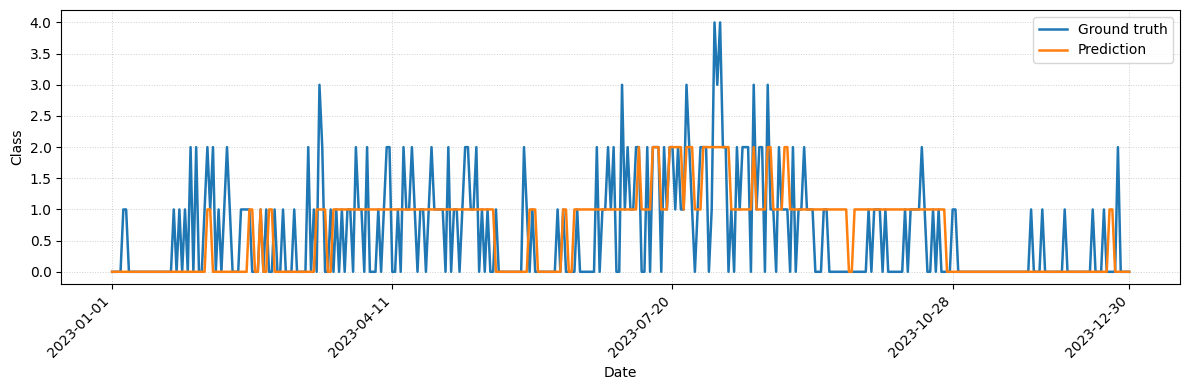

In [ ]:
plot_prediction(pred[pred['graph_id'] == 12], 'nbsinister-kmeans-5-Class-Dept', 'prediction_nbsinister-kmeans-5-Class-Dept', step=100)

In [ ]:
dataset.departement.unique().shape, dataset.date.unique().shape, dataset[dataset['nbsinister'] > 0].date.unique().shape

((92,), (2758,), (2192,))

In [ ]:
dataset.shape

(253736, 468)